# Projeto Final: Steelproof
## Etapa 2: Código da Solução

Previsão da temperatura final do aço no refino em panela para redução do consumo de energia.

Este notebook implementa o processo definido no Plano de Trabalho aprovado na Etapa 1. Ele parte dos sete arquivos originais e vai até a avaliação do modelo escolhido, cobrindo limpeza, construção da base analítica, preparação, modelagem e diagnóstico.

### Decisões herdadas da Etapa 1

O plano aprovado fixou os seguintes pontos, que são aplicados aqui sem nova discussão:

A variável-alvo é a última medição válida de temperatura de cada lote. Só entram na modelagem os lotes com pelo menos duas medições válidas, para que a temperatura anterior possa ser usada como preditor sem coincidir com o alvo.

A junção é mista: interna entre temperatura e arco, que são obrigatórias, e à esquerda para as demais fontes, cuja ausência significa material não utilizado e vira zero.

Os algoritmos são Regressão Linear, Random Forest, LightGBM e CatBoost, comparados contra baselines de referência.

### Hipótese de trabalho

As perguntas de esclarecimento da Etapa 1 não foram respondidas até a elaboração deste notebook. A mais relevante delas, sobre o momento em que a previsão é consumida, define quais atributos são temporalmente válidos.

Na ausência de resposta, mantém-se a hipótese declarada no plano: **Cenário B, previsão entre iterações**, em que o operador conhece as medições anteriores e a energia já aplicada, e decide quanto aquecer. O KPI correspondente é MAE abaixo de 4,5 °C, contra o baseline de 5,26 °C obtido ao simplesmente repetir a última leitura.

Para tornar a premissa verificável, a base é construída em duas versões, recortada e acumulada, e a diferença de desempenho entre elas quantifica quanto do resultado dependeria de informação indisponível na operação.

### Ajustes em relação ao plano

Dois pontos mudaram, ambos justificados no corpo do notebook:

A divisão treino/teste passa a ser cronológica em vez de aleatória estratificada, pela deriva temporal identificada na seção 4.1.

A base acumulada recebe apenas o melhor modelo, sem otimização de hiperparâmetros, já que seu papel é servir de referência de comparação e não de candidata a solução.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score, RandomizedSearchCV, KFold, TimeSeriesSplit, train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.inspection import permutation_importance

from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)
sns.set(style='whitegrid')

RANDOM_STATE = 12345
PASTA = '/datasets/'

print('Bibliotecas carregadas.')

Bibliotecas carregadas.


## 1. Carga dos dados

Os sete arquivos vêm de sistemas diferentes da planta e se conectam pela coluna `key`, que identifica o lote de aço.

In [2]:
arquivos = {
    'arc'       : 'data_arc_en.csv',
    'bulk'      : 'data_bulk_en.csv',
    'bulk_time' : 'data_bulk_time_en.csv',
    'gas'       : 'data_gas_en.csv',
    'temp'      : 'data_temp_en.csv',
    'wire'      : 'data_wire_en.csv',
    'wire_time' : 'data_wire_time_en.csv',
}

dados = {nome: pd.read_csv(PASTA + arquivo) for nome, arquivo in arquivos.items()}

arc       = dados['arc']
bulk      = dados['bulk']
bulk_time = dados['bulk_time']
gas       = dados['gas']
temp      = dados['temp']
wire      = dados['wire']
wire_time = dados['wire_time']

resumo = pd.DataFrame([
    {
        'arquivo'         : arquivos[nome],
        'linhas'          : df.shape[0],
        'colunas'         : df.shape[1],
        'lotes'           : df['key'].nunique(),
        'linhas_por_lote' : round(df.shape[0] / df['key'].nunique(), 2),
        'duplicadas'      : df.duplicated().sum(),
        'nulos'           : int(df.isna().sum().sum()),
    }
    for nome, df in dados.items()
])

resumo

,arquivo,linhas,colunas,lotes,linhas_por_lote,duplicadas,nulos
0,data_arc_en.csv,14876,5,3214,4.63,0,0
1,data_bulk_en.csv,3129,16,3129,1.00,0,35776
2,data_bulk_time_en.csv,3129,16,3129,1.00,0,35776
3,data_gas_en.csv,3239,2,3239,1.00,0,0
4,data_temp_en.csv,15907,3,3216,4.95,0,2901
5,data_wire_en.csv,3081,10,3081,1.00,0,23385
6,data_wire_time_en.csv,3081,10,3081,1.00,0,23385


Dois grupos se distinguem pela granularidade. Os arquivos `data_arc_en` e `data_temp_en` têm várias linhas por lote, uma para cada iteração do tratamento, e precisarão ser agregados. Os outros cinco já vêm com uma linha por lote.

Nenhum arquivo apresenta linhas duplicadas. Os valores ausentes se concentram nos arquivos de material, e a seção 2 mostra por que essa ausência não representa dado perdido.

## 2. Processamento e limpeza dos dados

Esta seção trata tipos de dados, duplicados, valores ausentes e inconsistências físicas. Cada decisão é registrada com a contagem de registros afetados, para que o efeito da limpeza seja rastreável.

### 2.1 Ajuste dos tipos de dados

Todas as colunas de horário foram lidas como texto. Enquanto permanecerem assim, não é possível calcular intervalos, e é justamente da diferença entre início e fim do arco que sai a duração do aquecimento, uma das variáveis mais importantes do modelo.

Quatro arquivos contêm colunas de horário: `data_arc_en`, `data_temp_en`, `data_bulk_time_en` e `data_wire_time_en`.

In [3]:
temp['Sampling time'] = pd.to_datetime(temp['Sampling time'])

arc['Arc heating start'] = pd.to_datetime(arc['Arc heating start'])
arc['Arc heating end']   = pd.to_datetime(arc['Arc heating end'])

for col in bulk_time.columns.drop('key'):
    bulk_time[col] = pd.to_datetime(bulk_time[col])

for col in wire_time.columns.drop('key'):
    wire_time[col] = pd.to_datetime(wire_time[col])

print('Tipos após a conversão:')
print('temp      :', temp.dtypes['Sampling time'])
print('arc       :', arc.dtypes['Arc heating start'], '|', arc.dtypes['Arc heating end'])
print('bulk_time :', bulk_time.dtypes.drop('key').unique())
print('wire_time :', wire_time.dtypes.drop('key').unique())
print()
print('Período coberto pelos dados:',
      temp['Sampling time'].min().date(), 'a', temp['Sampling time'].max().date())

Tipos após a conversão:
temp      : datetime64[ns]
arc       : datetime64[ns] | datetime64[ns]
bulk_time : [dtype('<M8[ns]')]
wire_time : [dtype('<M8[ns]')]

Período coberto pelos dados: 2019-05-03 a 2019-09-01


### 2.2 Registros duplicados

A verificação vai além da duplicidade de linha inteira. Também é preciso checar duplicidade lógica: dois registros de medição para o mesmo lote no mesmo instante, ou dois ciclos de arco iniciando ao mesmo tempo, indicariam falha de registro mesmo que os demais valores diferissem.

In [4]:
print('Linhas integralmente duplicadas:')
for nome, df in dados.items():
    print(f'  {nome:10s} {df.duplicated().sum()}')

print()
print('Duplicidade lógica:')
print('  temp, mesmo lote e mesmo instante de medição :',
      temp.duplicated(subset=['key', 'Sampling time']).sum())
print('  arc, mesmo lote e mesmo início de aquecimento:',
      arc.duplicated(subset=['key', 'Arc heating start']).sum())

Linhas integralmente duplicadas:
  arc        0
  bulk       0
  bulk_time  0
  gas        0
  temp       0
  wire       0
  wire_time  0

Duplicidade lógica:
  temp, mesmo lote e mesmo instante de medição : 0
  arc, mesmo lote e mesmo início de aquecimento: 0


Nenhuma duplicidade foi encontrada, nem de linha inteira nem lógica. Os arquivos de material têm uma linha por lote por construção, o que dispensa verificação adicional.

### 2.3 Valores ausentes

Os ausentes aparecem em dois contextos com significados opostos, e por isso recebem tratamentos diferentes.

In [5]:
print('Ausentes em data_temp_en:')
print(temp.isna().sum().to_string())
print(f"\nProporção de medições sem leitura registrada: "
      f"{temp['Temperature'].isna().mean() * 100:.1f}%")

print('\n' + '-' * 60)
print('Registros preenchidos por coluna em data_bulk_en:')
print(pd.DataFrame({
    'preenchidos': bulk.drop(columns='key').notna().sum(),
    'pct_ausente': (bulk.drop(columns='key').isna().mean() * 100).round(2),
}).to_string())

print('\nRegistros preenchidos por coluna em data_wire_en:')
print(pd.DataFrame({
    'preenchidos': wire.drop(columns='key').notna().sum(),
    'pct_ausente': (wire.drop(columns='key').isna().mean() * 100).round(2),
}).to_string())

Ausentes em data_temp_en:
key                 0
Sampling time       0
Temperature      2901

Proporção de medições sem leitura registrada: 18.2%

------------------------------------------------------------
Registros preenchidos por coluna em data_bulk_en:
         preenchidos  pct_ausente
Bulk 1           252        91.95
Bulk 2            22        99.30
Bulk 3          1298        58.52
Bulk 4          1014        67.59
Bulk 5            77        97.54
Bulk 6           576        81.59
Bulk 7            25        99.20
Bulk 8             1        99.97
Bulk 9            19        99.39
Bulk 10          176        94.38
Bulk 11          177        94.34
Bulk 12         2450        21.70
Bulk 13           18        99.42
Bulk 14         2806        10.32
Bulk 15         2248        28.16

Registros preenchidos por coluna em data_wire_en:
        preenchidos  pct_ausente
Wire 1         3055         0.84
Wire 2         1079        64.98
Wire 3           63        97.96
Wire 4          

**Ausente na temperatura significa falha de medição.** A leitura foi agendada mas não gravada. Como a temperatura é a variável-alvo, imputar seria inventar aquilo que se quer prever, e o modelo aprenderia a reproduzir a imputação. Essas linhas são descartadas.

O descarte é da linha da medição, não do lote. Um lote com seis medições, das quais duas sem leitura, permanece com quatro medições válidas.

**Ausente no material significa material não utilizado.** Se `Bulk 3` está vazio para um lote, nenhuma quantidade daquele material foi adicionada. O valor verdadeiro é zero. Imputar a média criaria adições de liga que nunca ocorreram e destruiria justamente o que diferencia um lote do outro. A substituição por zero é feita na seção 3, junto com a junção das fontes.

A contagem absoluta foi apresentada ao lado do percentual de propósito. `Bulk 8` e `Wire 5` aparecem como praticamente 100% ausentes, mas cada uma tem exatamente um registro preenchido em mais de três mil lotes. Não são colunas vazias, e sim colunas de uso pontual, que serão descartadas por variância insuficiente na seção 3.

In [6]:
temp_limpo = temp.dropna(subset=['Temperature']).copy()

print(f'Medições em data_temp_en          : {len(temp):>6}')
print(f'Removidas por falta de leitura    : {len(temp) - len(temp_limpo):>6}')
print(f'Medições válidas restantes        : {len(temp_limpo):>6}')

Medições em data_temp_en          :  15907
Removidas por falta de leitura    :   2901
Medições válidas restantes        :  13006


### 2.4 Consistência física dos registros

Além de ausentes e duplicados, os dados podem conter valores que são fisicamente impossíveis para o processo. Três verificações são feitas.

In [7]:
negativos = arc[arc['Reactive power'] < 0]
print('Ciclos com potência reativa negativa:', len(negativos))
display(negativos)

print('Faixa normal da potência reativa:')
print(arc.loc[arc['Reactive power'] >= 0, 'Reactive power'].describe().round(3).to_string())

Ciclos com potência reativa negativa: 1


,key,Arc heating start,Arc heating end,Active power,Reactive power
9780,2116,2019-07-24 00:44:48,2019-07-24 00:46:37,0.495782,-715.504924


Faixa normal da potência reativa:
count    14875.000
mean         0.501
std          0.311
min          0.021
25%          0.291
50%          0.416
75%          0.637
max          2.676


Um único registro, com valor de aproximadamente -715, enquanto a distribuição normal fica entre 0,02 e 2,68. O valor está três ordens de grandeza fora da faixa e com sinal invertido, o que aponta falha de sensor ou erro de gravação.

O ciclo é removido, e não o lote inteiro. O lote afetado tem outros ciclos de aquecimento íntegros, que continuam válidos.

In [8]:
arc_limpo = arc[arc['Reactive power'] >= 0].copy()

print(f'Ciclos de arco originais : {len(arc):>6}')
print(f'Removidos                : {len(arc) - len(arc_limpo):>6}')
print(f'Restantes                : {len(arc_limpo):>6}')

# Verificação 2: duração dos ciclos de aquecimento
arc_limpo['duracao_s'] = (arc_limpo['Arc heating end'] - arc_limpo['Arc heating start']).dt.total_seconds()

print('\nDuração dos ciclos, em segundos:')
print(arc_limpo['duracao_s'].describe().round(1).to_string())
print('\nCiclos com duração negativa:', (arc_limpo['duracao_s'] < 0).sum())
print('Ciclos com duração zero    :', (arc_limpo['duracao_s'] == 0).sum())

Ciclos de arco originais :  14876
Removidos                :      1
Restantes                :  14875

Duração dos ciclos, em segundos:
count    14875.0
mean       171.7
std         98.2
min         11.0
25%        107.0
50%        147.0
75%        214.0
max        907.0

Ciclos com duração negativa: 0
Ciclos com duração zero    : 0


Nenhum ciclo termina antes de começar e nenhum tem duração nula, o que confirma a consistência dos registros temporais de aquecimento.

In [9]:
# Verificação 3: leituras de temperatura fisicamente implausíveis
LIMITE_FISICO = 1400

implausiveis = temp_limpo[temp_limpo['Temperature'] < LIMITE_FISICO]
print(f'Leituras abaixo de {LIMITE_FISICO} °C:', len(implausiveis))
display(implausiveis.sort_values('Temperature'))

print('Sequência completa de medições do lote 1818:')
display(temp_limpo[temp_limpo['key'] == 1818].sort_values('Sampling time'))

Leituras abaixo de 1400 °C: 7


,key,Sampling time,Temperature
4350,867,2019-06-04 14:21:00,1191.0
12564,2561,2019-08-08 07:34:15,1204.0
5978,1214,2019-06-16 05:32:00,1208.0
7958,1619,2019-06-30 11:03:54,1218.0
10127,2052,2019-07-21 14:51:40,1227.0
8913,1818,2019-07-07 00:30:49,1383.0
8914,1818,2019-07-07 00:31:40,1383.0


Sequência completa de medições do lote 1818:


,key,Sampling time,Temperature
8907,1818,2019-07-07 00:00:14,1627.0
8908,1818,2019-07-07 00:13:02,1650.0
8909,1818,2019-07-07 00:25:28,1650.0
8910,1818,2019-07-07 00:26:03,1650.0
8911,1818,2019-07-07 00:26:42,1650.0
8912,1818,2019-07-07 00:27:23,1663.0
8913,1818,2019-07-07 00:30:49,1383.0
8914,1818,2019-07-07 00:31:40,1383.0
8915,1818,2019-07-07 00:32:55,1680.0
8916,1818,2019-07-07 00:36:11,1667.0


As sete leituras se concentram entre 1191 °C e 1383 °C, e depois há uma lacuna: nenhuma outra medição do conjunto fica abaixo de 1500 °C. O corte em 1400 °C cai no meio desse vazio e tem justificativa física, já que o aço carbono solidifica em torno de 1500 °C e não pode estar líquido na panela a 1383 °C.

A sequência do lote 1818 é a evidência mais direta. As duas leituras de 1383 °C aparecem entre uma de 1663 °C e uma de 1680 °C, num intervalo de dois minutos. Aço em panela de cem toneladas não perde 280 graus e recupera nesse tempo. É falha de sonda.

**O filtro é aplicado no nível da leitura, não do lote.** Essa escolha preserva dado: os lotes afetados mantêm suas medições íntegras e continuam na análise, em vez de serem descartados por causa de um registro defeituoso.

In [10]:
antes = len(temp_limpo)
temp_limpo = temp_limpo[temp_limpo['Temperature'] >= LIMITE_FISICO].copy()

print(f'Leituras válidas antes do filtro físico : {antes:>6}')
print(f'Removidas                               : {antes - len(temp_limpo):>6}')
print(f'Leituras válidas restantes              : {len(temp_limpo):>6}')
print(f'\nFaixa de temperatura após a limpeza: '
      f"{temp_limpo['Temperature'].min():.0f} a {temp_limpo['Temperature'].max():.0f} °C")

Leituras válidas antes do filtro físico :  13006
Removidas                               :      7
Leituras válidas restantes              :  12999

Faixa de temperatura após a limpeza: 1519 a 1705 °C


### 2.5 Critério de elegibilidade dos lotes

A variável-alvo é a última medição de temperatura do lote, e um dos preditores é a medição anterior a ela. Em lotes com uma única medição válida, essas duas seriam o mesmo registro, e o modelo receberia a resposta como pergunta.

Esse é um caso de vazamento de dados. Para evitá-lo, só entram na modelagem os lotes com pelo menos duas medições válidas.

In [11]:
medicoes_por_lote = temp_limpo.groupby('key')['Temperature'].count()

lotes_elegiveis = medicoes_por_lote[medicoes_por_lote >= 2].index

print(f'Lotes com ao menos uma medição válida : {len(medicoes_por_lote):>6}')
print(f'Lotes com apenas uma medição          : {(medicoes_por_lote == 1).sum():>6}')
print(f'Lotes elegíveis para modelagem        : {len(lotes_elegiveis):>6}')

print('\nDistribuição do número de medições por lote:')
print(medicoes_por_lote[medicoes_por_lote >= 2].value_counts().sort_index().to_string())

Lotes com ao menos uma medição válida :   3215
Lotes com apenas uma medição          :    740
Lotes elegíveis para modelagem        :   2475

Distribuição do número de medições por lote:
2      56
3     432
4     652
5     584
6     369
7     182
8     100
9      43
10     22
11     16
12     11
13      1
14      1
15      3
16      3


O critério descarta 740 lotes, cerca de 23% do conjunto. O custo é aceitável: manter dado contaminado por vazamento não produz um modelo pior, produz um modelo cujo desempenho medido não significa nada.

Ao final da limpeza restam 2.475 lotes elegíveis, sobre os quais a base analítica será construída.

## 3. Construção da base analítica

O problema é definido por lote, mas os dados de temperatura e aquecimento chegam em nível de evento. Esta seção agrega tudo por `key` e une as sete fontes em uma tabela com uma linha por lote.

Conforme a hipótese de trabalho, a base é construída em duas versões:

**Recortada.** Todas as agregações são limitadas ao instante da decisão, definido como o momento da penúltima medição de temperatura. É a base oficial, porque corresponde ao que o operador conhece quando decide o último aquecimento.

**Acumulada.** As agregações cobrem o lote inteiro. Serve como teto de referência, e a diferença de desempenho entre as duas quantifica quanto do resultado dependeria de informação ainda inexistente no momento da previsão.

### 3.1 Alvo e instante da decisão

A posição de cada medição dentro do lote é marcada com `cumcount`, contando do fim. A posição 0 é a última medição, que define o alvo, e a posição 1 é a penúltima, que define o instante do corte.

Esse caminho foi escolhido em vez de `groupby.nth()` porque o comportamento de `nth` quanto ao índice retornado varia entre versões do pandas, o que produziria associação errada entre lote e horário sem gerar nenhum erro visível.


In [12]:
temp_ord = temp_limpo.sort_values(['key', 'Sampling time']).copy()
temp_ord['pos_do_fim']    = temp_ord.groupby('key').cumcount(ascending=False)
temp_ord['pos_do_inicio'] = temp_ord.groupby('key').cumcount()

# mantém apenas os lotes elegíveis
temp_ord = temp_ord[temp_ord['key'].isin(lotes_elegiveis)].copy()

ultima_med   = temp_ord[temp_ord['pos_do_fim'] == 0].set_index('key')
penultima_med = temp_ord[temp_ord['pos_do_fim'] == 1].set_index('key')
primeira_med = temp_ord[temp_ord['pos_do_inicio'] == 0].set_index('key')

alvo    = ultima_med['Temperature'].rename('temp_final')
t_corte = penultima_med['Sampling time'].rename('t_corte')

print(f'Lotes com alvo definido : {len(alvo)}')
print(f'Instantes de corte      : {len(t_corte)}')

print('\nValidação em um lote de exemplo (key = 3):')
display(temp_ord[temp_ord['key'] == 3][['key', 'Sampling time', 'Temperature', 'pos_do_fim']])
print(f"Alvo (última medição)      : {alvo.loc[3]:.0f} °C")
print(f"Instante do corte          : {t_corte.loc[3]}")

Lotes com alvo definido : 2475
Instantes de corte      : 2475

Validação em um lote de exemplo (key = 3):


,key,Sampling time,Temperature,pos_do_fim
11,3,2019-05-03 12:13:17,1596.0,4
12,3,2019-05-03 12:18:36,1597.0,3
13,3,2019-05-03 12:25:06,1598.0,2
14,3,2019-05-03 12:30:48,1599.0,1
15,3,2019-05-03 12:34:57,1599.0,0


Alvo (última medição)      : 1599 °C
Instante do corte          : 2019-05-03 12:30:48


### 3.2 Agregação das medições de temperatura

Só entram as medições até o instante do corte, ou seja, as de posição 1 ou maior contando do fim. A última medição fica de fora por ser o alvo.

A variável `temp_penultima` merece destaque. Ela é a leitura mais recente disponível no momento da decisão e, como a Etapa 1 mostrou, tem correlação de 0,913 com o alvo. Não é vazamento: é exatamente o que o operador tem na mão. O critério de vazamento é temporal e não estatístico, e essa informação existe antes da previsão.

In [13]:
ate_corte = temp_ord[temp_ord['pos_do_fim'] >= 1]

agg_temp = ate_corte.groupby('key').agg(
    temp_inicial         = ('Temperature', 'first'),
    temp_media_ate_corte = ('Temperature', 'mean'),
    temp_max_ate_corte   = ('Temperature', 'max'),
    temp_min_ate_corte   = ('Temperature', 'min'),
    n_medicoes_ate_corte = ('Temperature', 'count'),
)

agg_temp['temp_penultima']       = penultima_med['Temperature']
agg_temp['delta_temp_ate_corte'] = agg_temp['temp_penultima'] - agg_temp['temp_inicial']
agg_temp['tempo_tratamento_s']   = (t_corte - primeira_med['Sampling time']).dt.total_seconds()

print('Atributos de temperatura construídos:', agg_temp.shape)
display(agg_temp.describe().round(2))

Atributos de temperatura construídos: (2475, 8)


,temp_inicial,temp_media_ate_corte,temp_max_ate_corte,temp_min_ate_corte,n_medicoes_ate_corte,temp_penultima,delta_temp_ate_corte,tempo_tratamento_s
count,2475.00,2475.00,2475.00,2475.00,2475.00,2475.00,2475.00,2475.00
mean,1589.03,1590.17,1601.02,1579.24,3.95,1592.78,3.75,1577.83
std,25.00,17.27,19.60,18.61,1.80,16.49,22.11,1310.96
min,1519.00,1544.67,1550.00,1519.00,1.00,1537.00,-102.00,0.00
25%,1572.00,1579.75,1588.50,1569.00,3.00,1584.00,-11.00,896.00
50%,1588.00,1589.00,1598.00,1580.00,4.00,1591.00,4.00,1327.00
75%,1605.00,1598.78,1612.00,1589.00,5.00,1598.00,18.00,1994.00
max,1679.00,1677.25,1705.00,1661.00,15.00,1705.00,103.00,23101.00


### 3.3 Agregação dos ciclos de aquecimento

A energia de cada ciclo é calculada como o produto entre potência ativa e duração, e só depois somada por lote. A ordem importa: somar potências e durações separadamente para multiplicar os totais daria um número sem significado físico.

A base é a relação térmica do processo. O calor necessário para elevar a temperatura de uma massa é proporcional à energia aplicada, e energia é potência multiplicada por tempo. Como a massa da panela é aproximadamente constante, a variação de temperatura acompanha o produto entre potência e duração.

Na versão recortada entram apenas os ciclos que **terminaram** até o instante do corte. Na acumulada entram todos.

In [14]:
arc_limpo['energia'] = arc_limpo['Active power'] * arc_limpo['duracao_s']

def agregar_arco(df):
    return df.groupby('key').agg(
        pot_ativa_total   = ('Active power',   'sum'),
        pot_ativa_media   = ('Active power',   'mean'),
        pot_reativa_total = ('Reactive power', 'sum'),
        duracao_total_s   = ('duracao_s',      'sum'),
        n_ciclos_arco     = ('Active power',   'count'),
        energia_total     = ('energia',        'sum'),
    )

arc_com_corte = arc_limpo.merge(t_corte, left_on='key', right_index=True, how='inner')
arc_recortado = arc_com_corte[arc_com_corte['Arc heating end'] <= arc_com_corte['t_corte']]

agg_arco_rec = agregar_arco(arc_recortado)
ultimo_arco  = arc_recortado.groupby('key')['Arc heating end'].max()
agg_arco_rec['tempo_desde_arco_s'] = (t_corte.reindex(agg_arco_rec.index) - ultimo_arco).dt.total_seconds()

agg_arco_acu = agregar_arco(arc_limpo[arc_limpo['key'].isin(alvo.index)])

print(f'Ciclos de arco totais            : {len(arc_limpo[arc_limpo["key"].isin(alvo.index)]):>6}')
print(f'Ciclos encerrados até o corte    : {len(arc_recortado):>6}')
print(f'Lotes com aquecimento até o corte: {len(agg_arco_rec):>6} de {len(alvo)}')

Ciclos de arco totais            :  11448
Ciclos encerrados até o corte    :   9414
Lotes com aquecimento até o corte:   2471 de 2475


Alguns lotes não têm nenhum ciclo de aquecimento encerrado antes do corte. Nesses casos todo o arco ocorreu depois da penúltima medição, e sob a hipótese adotada não haveria histórico de aquecimento disponível para a previsão. Eles saem da base recortada.

### 3.4 Materiais adicionados

Os arquivos de volume e de horário são espelhos: mesma dimensão e mesmo padrão de ausência, célula a célula. Isso permite filtrar as adições pelo instante em que ocorreram.

Na versão recortada só entram as adições feitas até o corte. As demais são tratadas como ainda não ocorridas.

In [15]:
def preparar_materiais(volumes, horarios, prefixo, corte=None):
    v = volumes.set_index('key')
    h = horarios.set_index('key')
    v.columns = [f'{prefixo}_{i}' for i in range(1, v.shape[1] + 1)]
    h.columns = v.columns

    if corte is not None:
        adicionado_antes = h.le(corte.reindex(h.index), axis=0)
        v = v.where(adicionado_antes)
    return v

bulk_rec = preparar_materiais(bulk, bulk_time, 'bulk', t_corte)
wire_rec = preparar_materiais(wire, wire_time, 'wire', t_corte)

bulk_acu = preparar_materiais(bulk, bulk_time, 'bulk')
wire_acu = preparar_materiais(wire, wire_time, 'wire')

gas_idx = gas.set_index('key')
gas_idx.columns = ['gas']

elegiveis = alvo.index
adicoes_totais = int(bulk_acu.loc[bulk_acu.index.isin(elegiveis)].notna().sum().sum()
                     + wire_acu.loc[wire_acu.index.isin(elegiveis)].notna().sum().sum())
adicoes_antes  = int(bulk_rec.loc[bulk_rec.index.isin(elegiveis)].notna().sum().sum()
                     + wire_rec.loc[wire_rec.index.isin(elegiveis)].notna().sum().sum())

print(f'Adições de material nos lotes elegíveis : {adicoes_totais:>6}')
print(f'Realizadas até o instante do corte      : {adicoes_antes:>6} '
      f'({adicoes_antes / adicoes_totais * 100:.1f}%)')

Adições de material nos lotes elegíveis :  11856
Realizadas até o instante do corte      :  11370 (95.9%)


A grande maioria das adições ocorre antes do corte, então o recorte temporal preserva quase toda a informação de composição química.

O volume de gás inerte fica de fora da base recortada. O arquivo `data_gas_en` traz apenas o total por lote, sem horário associado, o que impede o recorte temporal. Como não há como saber quanto de gás já havia sido purgado no instante da decisão, incluí-lo violaria o critério adotado. A perda é pequena: a Etapa 1 mediu correlação de -0,033 entre gás e temperatura final.

Essa é uma limitação dos dados e está registrada na seção 8.3.

### 3.5 Junção das fontes e descarte de atributos sem variância

In [16]:
def montar_base(agg_arco, materiais_bulk, materiais_wire, incluir_gas):
    base = (pd.DataFrame(alvo)
            .join(agg_temp,   how='inner')
            .join(agg_arco,   how='inner')
            .join(materiais_bulk, how='left')
            .join(materiais_wire, how='left'))

    if incluir_gas:
        base = base.join(gas_idx, how='left').dropna(subset=['gas'])

    colunas_material = [c for c in base.columns if c.startswith(('bulk_', 'wire_'))]
    base[colunas_material] = base[colunas_material].fillna(0)
    return base

base_recortada = montar_base(agg_arco_rec, bulk_rec, wire_rec, incluir_gas=False)
base_acumulada = montar_base(agg_arco_acu, bulk_acu, wire_acu, incluir_gas=True)

sem_variancia = [c for c in base_recortada.columns
                 if base_recortada[c].nunique() <= 2 and (base_recortada[c] != 0).sum() <= 1]

base_recortada = base_recortada.drop(columns=sem_variancia)
base_acumulada = base_acumulada.drop(columns=sem_variancia, errors='ignore')

print('Atributos descartados por variância insuficiente:', sem_variancia)
print()
print(f'Base recortada : {base_recortada.shape[0]} lotes, {base_recortada.shape[1] - 1} preditores')
print(f'Base acumulada : {base_acumulada.shape[0]} lotes, {base_acumulada.shape[1] - 1} preditores')

Atributos descartados por variância insuficiente: ['bulk_8', 'wire_5']

Base recortada : 2471 lotes, 37 preditores
Base acumulada : 2473 lotes, 37 preditores


### 3.6 Verificação de integridade

Três checagens antes de seguir para a preparação.

In [17]:
print('1. Valores ausentes')
print(f'   recortada: {base_recortada.isna().sum().sum()} | acumulada: {base_acumulada.isna().sum().sum()}')

print('\n2. A coluna key não pode ser preditor')
print(f"   'key' entre as colunas da base: {'key' in base_recortada.columns}")
print('   Motivo: key acompanha a ordem cronológica dos lotes e o modelo aprenderia')
print('   tendência temporal em vez da física do processo.')

print('\n3. Atributos constantes remanescentes')
constantes = [c for c in base_recortada.columns if base_recortada[c].nunique() <= 1]
print(f'   {constantes if constantes else "nenhum"}')

print('\nAmostra da base recortada:')
display(base_recortada.head(3))

1. Valores ausentes
   recortada: 0 | acumulada: 0

2. A coluna key não pode ser preditor
   'key' entre as colunas da base: False
   Motivo: key acompanha a ordem cronológica dos lotes e o modelo aprenderia
   tendência temporal em vez da física do processo.

3. Atributos constantes remanescentes
   nenhum

Amostra da base recortada:


,temp_final,temp_inicial,temp_media_ate_corte,temp_max_ate_corte,temp_min_ate_corte,n_medicoes_ate_corte,temp_penultima,delta_temp_ate_corte,tempo_tratamento_s,pot_ativa_total,pot_ativa_media,pot_reativa_total,duracao_total_s,n_ciclos_arco,energia_total,tempo_desde_arco_s,bulk_1,bulk_2,bulk_3,bulk_4,bulk_5,bulk_6,bulk_7,bulk_9,bulk_10,bulk_11,bulk_12,bulk_13,bulk_14,bulk_15,wire_1,wire_2,wire_3,wire_4,wire_6,wire_7,wire_8,wire_9
key,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
1,1613.0,1571.0,1598.5,1618.0,1571.0,4,1601.0,30.0,823.0,4.878147,0.975629,3.183241,1098.0,5,1207.804249,84.0,0.0,0.0,0.0,43.0,0.0,0.0,0.0,0.0,0.0,0.0,206.0,0.0,150.0,154.0,60.059998,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,1602.0,1581.0,1591.8,1608.0,1577.0,5,1608.0,27.0,1257.0,3.052598,0.763150,1.998112,811.0,4,733.816470,306.0,0.0,0.0,0.0,73.0,0.0,0.0,0.0,0.0,0.0,0.0,206.0,0.0,149.0,154.0,96.052315,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,1599.0,1596.0,1597.5,1599.0,1596.0,4,1599.0,3.0,1051.0,2.275602,0.568901,1.443175,590.0,4,427.315133,228.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,205.0,0.0,152.0,153.0,91.160157,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## 4. Preparação dos dados para a modelagem

### 4.1 Verificação da natureza temporal

O plano aprovado previa divisão aleatória estratificada por faixa de temperatura. Antes de aplicá-la, é preciso verificar se os dados têm estrutura temporal que torne essa escolha inadequada.

Cada lote tem data, e a coluna `key` acompanha a ordem cronológica. Se houver deriva no processo ao longo do período, uma divisão aleatória misturaria passado e futuro no treino, o que produz uma estimativa otimista: o modelo teria visto lotes contemporâneos aos do teste.

In [18]:
data_lote = primeira_med.loc[base_recortada.index, 'Sampling time'].rename('data_lote')

print('Período coberto:', data_lote.min().date(), 'a', data_lote.max().date())
print('Duração:', (data_lote.max() - data_lote.min()).days, 'dias')
print('\nCorrelação entre a coluna key e a data do lote:',
      round(pd.Series(base_recortada.index).corr(pd.Series(data_lote.values.astype('int64'))), 4))

evolucao = pd.DataFrame({'data': data_lote, 'temp_final': base_recortada['temp_final']})
evolucao['mes'] = evolucao['data'].dt.to_period('M')

print('\nTemperatura final por mês:')
print(evolucao.groupby('mes')['temp_final'].agg(['count', 'mean', 'std']).round(2).to_string())

Período coberto: 2019-05-03 a 2019-08-06
Duração: 94 dias

Correlação entre a coluna key e a data do lote: 0.9983

Temperatura final por mês:
         count     mean    std
mes                           
2019-05    753  1596.82  16.58
2019-06    867  1595.13  15.54
2019-07    715  1594.21  14.88
2019-08    136  1594.20  20.13


O gráfico abaixo mostra a evolução do alvo ao longo do período, com média móvel para separar a tendência do ruído.

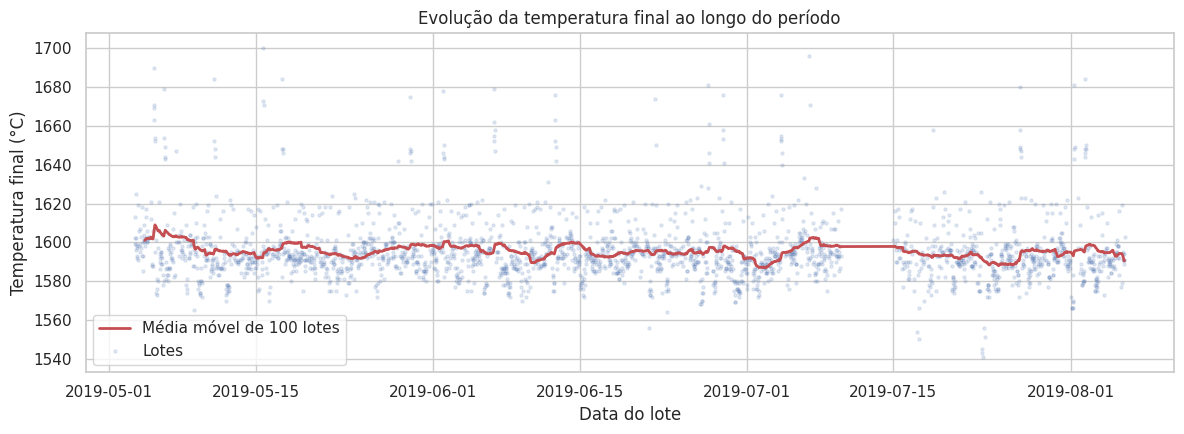

In [19]:
evolucao_ordenada = evolucao.sort_values('data')
media_movel = evolucao_ordenada['temp_final'].rolling(window=100, min_periods=30).mean()

fig, ax = plt.subplots(figsize=(12, 4.5))
ax.scatter(evolucao_ordenada['data'], evolucao_ordenada['temp_final'],
           s=5, alpha=0.15, color='#4c72b0', label='Lotes')
ax.plot(evolucao_ordenada['data'], media_movel,
        color='#c44e52', linewidth=2, label='Média móvel de 100 lotes')
ax.set_title('Evolução da temperatura final ao longo do período')
ax.set_xlabel('Data do lote')
ax.set_ylabel('Temperatura final (°C)')
ax.legend()
plt.tight_layout()
plt.show()

A coluna `key` acompanha quase perfeitamente a ordem cronológica, o que confirma a decisão da seção 3.6 de mantê-la fora dos preditores.

A média mensal cai de forma monotônica ao longo do período. A queda total é pequena diante do desvio padrão do alvo, mas não diante do erro que o modelo precisa atingir, o que basta para justificar a mudança de estratégia.

**A divisão passa a ser cronológica**, com os lotes mais antigos no treino e os mais recentes no teste. Isso simula o uso real, em que o modelo treina no histórico e prevê lotes futuros, e produz uma estimativa de erro que não depende de ter visto lotes do mesmo período.

O custo é abrir mão da estratificação por faixa de temperatura prevista no plano, já que as duas ordenações são incompatíveis. A seção 7.3 compensa isso avaliando o erro segmentado por faixa, e a seção 7.5 repete a avaliação com divisão aleatória como análise de sensibilidade.

### 4.2 Codificação de atributos não numéricos

O edital pede a codificação de atributos não numéricos para que possam ser interpretados pelos algoritmos. A verificação abaixo mostra que essa etapa não se aplica a este conjunto.

In [20]:
tipos = base_recortada.dtypes.value_counts()
print('Tipos presentes na base:')
print(tipos.to_string())

nao_numericas = base_recortada.select_dtypes(exclude=[np.number]).columns.tolist()
print('\nColunas não numéricas:', nao_numericas if nao_numericas else 'nenhuma')

Tipos presentes na base:
float64    36
int64       2

Colunas não numéricas: nenhuma


Todos os atributos são numéricos. As colunas categóricas em potencial, como o tipo de aço ou o identificador do material, não existem no conjunto fornecido, e a pergunta 6 da Etapa 1 pedia justamente essa informação.

As variáveis de material funcionam como indicadores de quantidade, com zero significando ausência de uso, o que já é uma representação numérica adequada e dispensa codificação adicional.

### 4.3 Divisão treino e teste

Proporção de 75% e 25%, com os lotes ordenados por data. O conjunto de teste é reservado desde agora e usado uma única vez, na avaliação.

In [21]:
PROPORCAO_TREINO = 0.75

ordem_cronologica = data_lote.sort_values().index
base_ordenada = base_recortada.loc[ordem_cronologica]

ponto_corte = int(len(base_ordenada) * PROPORCAO_TREINO)
treino = base_ordenada.iloc[:ponto_corte]
teste  = base_ordenada.iloc[ponto_corte:]

PREDITORES = [c for c in base_recortada.columns if c != 'temp_final']
ALVO = 'temp_final'

X_treino, y_treino = treino[PREDITORES], treino[ALVO]
X_teste,  y_teste  = teste[PREDITORES],  teste[ALVO]

print(f'Treino: {len(treino):>5} lotes | '
      f'{data_lote.loc[treino.index].min().date()} a {data_lote.loc[treino.index].max().date()}')
print(f'Teste : {len(teste):>5} lotes | '
      f'{data_lote.loc[teste.index].min().date()} a {data_lote.loc[teste.index].max().date()}')
print(f'\nPreditores: {len(PREDITORES)}')

print(f'\nTemperatura final média no treino: {y_treino.mean():.2f} °C')
print(f'Temperatura final média no teste : {y_teste.mean():.2f} °C')
print(f'Diferença                        : {y_teste.mean() - y_treino.mean():.2f} °C')

Treino:  1853 lotes | 2019-05-03 a 2019-07-08
Teste :   618 lotes | 2019-07-08 a 2019-08-06

Preditores: 37

Temperatura final média no treino: 1595.95 °C
Temperatura final média no teste : 1593.47 °C
Diferença                        : -2.48 °C


A diferença entre as médias confirma a deriva. O conjunto de teste é sistematicamente mais frio que o de treino, e essa diferença representa parcela relevante do erro que o modelo precisa atingir. Uma divisão aleatória esconderia esse deslocamento e produziria uma estimativa otimista.

### 4.4 Escalonamento

A regressão linear é sensível à escala das variáveis, que aqui vão de valores próximos de zero, nas adições de material, a milhares de segundos, na duração do tratamento. Os modelos baseados em árvores dispensam o escalonamento, porque dividem por limiar e não por distância.

O escalonador é encapsulado em um `Pipeline`. Isso garante que, durante a validação cruzada, a média e o desvio sejam calculados apenas nas partições de treino de cada rodada. Ajustar o escalonador sobre todo o conjunto antes da validação faria informação das partições de avaliação vazar para a transformação.

In [22]:
pipeline_linear = Pipeline([
    ('escalonador', StandardScaler()),
    ('modelo', LinearRegression()),
])

print('Pipeline definido:', [nome for nome, _ in pipeline_linear.steps])
print('\nAmplitude das variáveis antes do escalonamento:')
print(X_treino[['temp_penultima', 'energia_total', 'tempo_tratamento_s',
                'n_ciclos_arco', 'bulk_14']].describe().loc[['min', 'max']].round(2).to_string())

Pipeline definido: ['escalonador', 'modelo']

Amplitude das variáveis antes do escalonamento:
     temp_penultima  energia_total  tempo_tratamento_s  n_ciclos_arco  bulk_14
min          1550.0          10.61                 0.0            1.0      0.0
max          1705.0        8575.82             23101.0           15.0    636.0


### 4.5 Balanceamento

O edital cita o balanceamento de classes entre as estratégias de preparação. Ele não se aplica aqui: o alvo é contínuo e não existem classes a equilibrar.

O problema análogo em regressão é o desequilíbrio da distribuição do alvo. A temperatura final se concentra em uma faixa estreita com cauda longa, o que leva o modelo a acertar bem o centro e errar mais nos lotes atípicos. Esses lotes atípicos são justamente os de maior interesse operacional, porque são os que consomem mais energia.

Como a divisão passou a ser cronológica, a estratificação da partição deixou de estar disponível. Duas medidas ocupam esse lugar:

Avaliação do erro segmentada por faixa de temperatura, na seção 7.3, e não apenas do MAE global, que esconderia desempenho ruim nos extremos.

Comparação entre MAE e RMSE. Uma diferença grande entre as duas métricas indica que o erro está concentrado em poucos lotes de cauda, o que muda a recomendação operacional.

In [23]:
quartis = pd.qcut(y_treino, 4)
print('Distribuição do alvo no treino, por quartil:')
print(y_treino.groupby(quartis).agg(['count', 'min', 'max']).round(1).to_string())

print(f'\nAssimetria do alvo no treino: {y_treino.skew():.2f}')
print(f'Curtose do alvo no treino   : {y_treino.kurtosis():.2f}')

Distribuição do alvo no treino, por quartil:
                    count     min     max
temp_final                               
(1546.999, 1588.0]    497  1547.0  1588.0
(1588.0, 1593.0]      455  1589.0  1593.0
(1593.0, 1600.0]      485  1594.0  1600.0
(1600.0, 1700.0]      416  1601.0  1700.0

Assimetria do alvo no treino: 2.34
Curtose do alvo no treino   : 8.75


## 5. Modelagem

### 5.1 Modelos de referência

Nenhuma métrica significa alguma coisa sem referência. Dois baselines são usados.

**Média do treino.** Prevê sempre a temperatura média histórica. É a referência clássica e representa o que se sabe sem nenhum modelo.

**Repetir a última leitura.** Prevê que a temperatura final será igual à penúltima medição, ou seja, supõe que o último aquecimento não muda nada. É uma regra que se escreve em uma linha e está disponível ao operador sem esforço algum.

O segundo baseline é o exigente, e foi ele que definiu o KPI de 4,5 °C no plano da Etapa 1. Um modelo que não o supere não justifica sua existência.

In [24]:
cv_temporal = TimeSeriesSplit(n_splits=5)
cv_aleatoria = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

baseline_dummy = DummyRegressor(strategy='mean')
mae_dummy = -cross_val_score(baseline_dummy, X_treino, y_treino,
                             cv=cv_temporal, scoring='neg_mean_absolute_error').mean()

mae_repetir = (y_treino - X_treino['temp_penultima']).abs().mean()

print('Modelos de referência, avaliados no conjunto de treino')
print(f'  Prever sempre a média          : MAE = {mae_dummy:.2f} °C')
print(f'  Repetir a penúltima medição    : MAE = {mae_repetir:.2f} °C')
print(f'\n  KPI definido na Etapa 1        : MAE < 4,50 °C')

Modelos de referência, avaliados no conjunto de treino
  Prever sempre a média          : MAE = 10.27 °C
  Repetir a penúltima medição    : MAE = 5.31 °C

  KPI definido na Etapa 1        : MAE < 4,50 °C


### 5.2 Treinamento dos algoritmos em configuração padrão

Os quatro algoritmos previstos no plano são treinados sem ajuste de hiperparâmetros e comparados por validação cruzada em cinco partições dentro do conjunto de treino. O conjunto de teste permanece intocado.

A validação é feita de duas formas, e a comparação entre elas é informativa.

**Validação temporal.** Cada partição treina no passado e avalia no futuro, reproduzindo a lógica da divisão externa. É o critério de seleção adotado.

**Validação embaralhada.** As partições são sorteadas sem considerar a ordem. Serve de contraste, para medir o quanto a exigência temporal afeta cada algoritmo.

In [25]:
modelos = {
    'Regressão Linear': Pipeline([
        ('escalonador', StandardScaler()),
        ('modelo', LinearRegression()),
    ]),
    'Random Forest': RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1),
    'LightGBM': LGBMRegressor(random_state=RANDOM_STATE, verbose=-1),
    'CatBoost': CatBoostRegressor(random_state=RANDOM_STATE, verbose=0),
}

resultados = []

for nome, modelo in modelos.items():
    mae_temp = -cross_val_score(modelo, X_treino, y_treino,
                                cv=cv_temporal, scoring='neg_mean_absolute_error')
    mae_alea = -cross_val_score(modelo, X_treino, y_treino,
                                cv=cv_aleatoria, scoring='neg_mean_absolute_error')
    resultados.append({
        'modelo'          : nome,
        'cv_temporal'     : mae_temp.mean(),
        'desvio_temporal' : mae_temp.std(),
        'cv_aleatoria'    : mae_alea.mean(),
        'desvio_aleatoria': mae_alea.std(),
    })
    print(f'{nome:18s} temporal={mae_temp.mean():.3f}  aleatória={mae_alea.mean():.3f}')

comparacao = pd.DataFrame(resultados).set_index('modelo').round(3)
comparacao['atinge_kpi'] = comparacao['cv_temporal'] < 4.5

print()
display(comparacao)

Regressão Linear   temporal=4.563  aleatória=4.441
Random Forest      temporal=4.223  aleatória=4.170
LightGBM           temporal=4.488  aleatória=4.178
CatBoost           temporal=4.248  aleatória=4.011



,cv_temporal,desvio_temporal,cv_aleatoria,desvio_aleatoria,atinge_kpi
modelo,,,,,
Regressão Linear,4.563,0.336,4.441,0.252,False
Random Forest,4.223,0.189,4.170,0.232,True
LightGBM,4.488,0.417,4.178,0.280,True
CatBoost,4.248,0.253,4.011,0.209,True


Três leituras.

**Todos os algoritmos superam os dois baselines**, inclusive a regressão linear. Isso valida a construção das features: se o modelo mais simples já ganha da regra ingênua, o sinal está nos atributos e não em artifício do algoritmo.

**A ordem muda entre os dois critérios de validação.** Na validação embaralhada o LightGBM aparece empatado no topo. Na temporal ele cai abaixo do Random Forest e do CatBoost, com desvio entre partições bem maior que o dos demais. O modelo é o mais sensível à deriva identificada na seção 4.1, e a validação embaralhada esconderia isso.

**A seleção segue o critério temporal**, por ser o coerente com a divisão externa e com o uso real. Os dois modelos escolhidos para otimização são **Random Forest e CatBoost**.

Uma ressalva sobre a validação temporal: as primeiras partições treinam com bem menos dados que as últimas, o que torna as estimativas mais pessimistas e a variância entre partições maior. Isso é uma característica do método, não um defeito dos modelos, e por isso a comparação entre algoritmos continua válida.

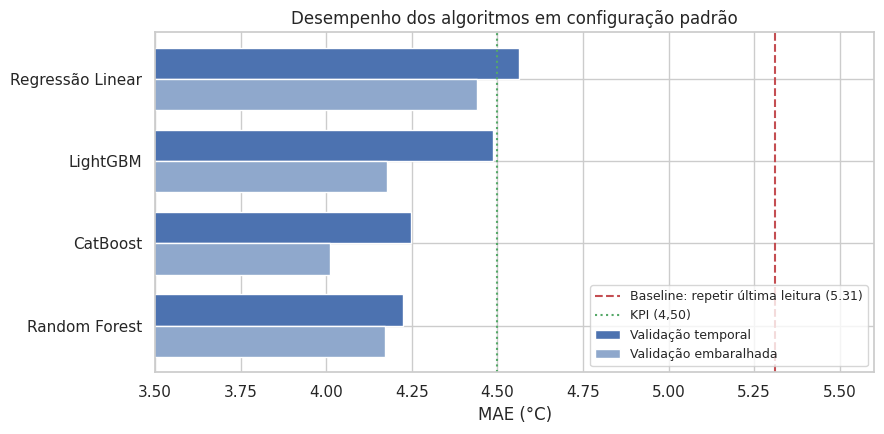

In [26]:
grafico = comparacao[['cv_temporal', 'cv_aleatoria']].sort_values('cv_temporal')

fig, ax = plt.subplots(figsize=(9, 4.5))
posicao = np.arange(len(grafico))
largura = 0.38

ax.barh(posicao + largura/2, grafico['cv_temporal'], largura,
        label='Validação temporal', color='#4c72b0')
ax.barh(posicao - largura/2, grafico['cv_aleatoria'], largura,
        label='Validação embaralhada', color='#8fa8cc')

ax.axvline(mae_repetir, color='#c44e52', linestyle='--', linewidth=1.5,
           label=f'Baseline: repetir última leitura ({mae_repetir:.2f})')
ax.axvline(4.5, color='#55a868', linestyle=':', linewidth=1.5, label='KPI (4,50)')

ax.set_yticks(posicao)
ax.set_yticklabels(grafico.index)
ax.set_xlabel('MAE (°C)')
ax.set_title('Desempenho dos algoritmos em configuração padrão')
ax.set_xlim(3.5, 5.6)
ax.legend(loc='lower right', fontsize=9)
plt.tight_layout()
plt.show()

### 5.3 Modelos selecionados para otimização

Random Forest e CatBoost seguem para o ajuste de hiperparâmetros. O LightGBM fica de fora apesar do bom resultado na validação embaralhada, pelo comportamento instável sob validação temporal.

A regressão linear cumpriu seu papel de referência interpretável e não segue adiante, já que os dois ensembles a superam em ambos os critérios.

## 6. Otimização e avaliação final

### 6.1 Ajuste de hiperparâmetros

A busca é feita com `RandomizedSearchCV`, mais eficiente que a busca exaustiva quando o espaço é amplo. A validação usada é a temporal, a mesma que orientou a seleção da seção 5.2.

Os espaços foram montados em torno dos parâmetros que controlam a complexidade do modelo, porque o problema a resolver não é o erro médio, que os modelos padrão já atingem, e sim o sobreajuste. Com apenas 1.853 lotes de treino, ambos os algoritmos memorizam o conjunto se deixados sem restrição.

In [27]:
espaco_random_forest = {
    'n_estimators'     : [100, 200, 300, 400],
    'max_depth'        : [4, 6, 8, 10, None],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf' : [1, 2, 4, 8, 16],
    'max_features'     : [0.3, 0.5, 0.7, 1.0],
}

espaco_catboost = {
    'depth'        : [3, 4, 5, 6, 8],
    'learning_rate': [0.02, 0.05, 0.08, 0.1],
    'iterations'   : [300, 500, 800],
    'l2_leaf_reg'  : [1, 3, 5, 10, 20],
}

buscas = {
    'Random Forest': RandomizedSearchCV(
        RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1),
        espaco_random_forest, n_iter=30, cv=cv_temporal,
        scoring='neg_mean_absolute_error', random_state=RANDOM_STATE, n_jobs=-1),
    'CatBoost': RandomizedSearchCV(
        CatBoostRegressor(random_state=RANDOM_STATE, verbose=0),
        espaco_catboost, n_iter=25, cv=cv_temporal,
        scoring='neg_mean_absolute_error', random_state=RANDOM_STATE, n_jobs=-1),
}

otimizados = {}
for nome, busca in buscas.items():
    busca.fit(X_treino, y_treino)
    otimizados[nome] = busca.best_estimator_
    print(f'{nome}')
    print(f'  MAE na validação cruzada : {-busca.best_score_:.3f} °C')
    print(f'  Melhores parâmetros      : {busca.best_params_}')
    print()

Random Forest
  MAE na validação cruzada : 4.085 °C
  Melhores parâmetros      : {'n_estimators': 400, 'min_samples_split': 10, 'min_samples_leaf': 2, 'max_features': 0.5, 'max_depth': None}

CatBoost
  MAE na validação cruzada : 4.064 °C
  Melhores parâmetros      : {'learning_rate': 0.02, 'l2_leaf_reg': 3, 'iterations': 500, 'depth': 5}



### 6.2 Verificação de generalização

O edital lista modelos sobreajustados entre os motivos de reprovação, e o plano da Etapa 1 fixou o critério: a diferença entre o erro de treino e o de teste deve ficar abaixo de 15%.

Essa verificação é independente do erro médio. Um modelo pode ter o menor MAE da comparação e ainda assim não generalizar.

In [28]:
def avaliar(modelo, X_tr, y_tr, X_te, y_te):
    prev_treino = modelo.predict(X_tr)
    prev_teste  = modelo.predict(X_te)

    mae_treino = mean_absolute_error(y_tr, prev_treino)
    mae_teste  = mean_absolute_error(y_te, prev_teste)

    return {
        'mae_treino': mae_treino,
        'mae_teste' : mae_teste,
        'gap_pct'   : (mae_teste - mae_treino) / mae_teste * 100,
        'rmse_teste': mean_squared_error(y_te, prev_teste) ** 0.5,
        'r2_teste'  : r2_score(y_te, prev_teste),
    }

diagnostico = pd.DataFrame({
    nome: avaliar(modelo, X_treino, y_treino, X_teste, y_teste)
    for nome, modelo in otimizados.items()
}).T.round(3)

diagnostico['generaliza'] = diagnostico['gap_pct'] < 15
display(diagnostico)

,mae_treino,mae_teste,gap_pct,rmse_teste,r2_teste,generaliza
Random Forest,2.293,3.967,42.203,5.751,0.864,False
CatBoost,3.521,3.910,9.951,5.401,0.880,True


O resultado separa os dois modelos por um critério que o MAE sozinho não capturaria.

O Random Forest tem erro de teste competitivo, mas mantém diferença grande entre treino e teste mesmo depois da busca. A otimização escolheu a configuração menos restrita porque era a que minimizava o erro na validação, e minimizar erro de validação não é o mesmo que garantir generalização.

O CatBoost atinge erro de teste menor e diferença dentro do limite. A configuração escolhida tem profundidade baixa e taxa de aprendizado pequena, ou seja, a busca convergiu para um modelo deliberadamente contido.

**O modelo final é o CatBoost.**

### 6.3 Resultado no conjunto de teste

O conjunto de teste foi reservado na seção 4.3 e não participou de nenhuma etapa de seleção ou ajuste. Esta é a primeira e única vez que ele é usado.

In [29]:
modelo_final = otimizados['CatBoost']

previsao_teste = modelo_final.predict(X_teste)

mae_final  = mean_absolute_error(y_teste, previsao_teste)
rmse_final = mean_squared_error(y_teste, previsao_teste) ** 0.5
r2_final   = r2_score(y_teste, previsao_teste)

mae_base_media    = (y_teste - y_treino.mean()).abs().mean()
mae_base_repetir  = (y_teste - X_teste['temp_penultima']).abs().mean()

placar = pd.DataFrame([
    {'abordagem': 'Prever sempre a média do treino', 'mae': mae_base_media},
    {'abordagem': 'Repetir a penúltima medição',     'mae': mae_base_repetir},
    {'abordagem': 'CatBoost otimizado',              'mae': mae_final},
]).set_index('abordagem')

placar['reducao_vs_regra_ingenua_pct'] = (
    (mae_base_repetir - placar['mae']) / mae_base_repetir * 100)
placar.loc['Repetir a penúltima medição', 'reducao_vs_regra_ingenua_pct'] = np.nan

print('Desempenho no conjunto de teste')
display(placar.round(2))

Desempenho no conjunto de teste


,mae,reducao_vs_regra_ingenua_pct
abordagem,,
Prever sempre a média do treino,10.64,-109.82
Repetir a penúltima medição,5.07,NaN
CatBoost otimizado,3.91,22.92


O modelo atende aos dois KPIs definidos na Etapa 1, e o faz contra o baseline exigente. Reduzir o erro em relação à média histórica seria fácil; superar a regra de repetir a última leitura é o que caracteriza ganho real.

A razão entre RMSE e MAE indica quanto o erro se concentra em poucos lotes. Uma razão próxima de 1,25 corresponde a erros bem distribuídos. Valores acima disso apontam cauda pesada, ou seja, o modelo acerta a maioria e erra bastante em alguns casos, o que é analisado na seção 7.3.

## 7. Diagnóstico do modelo

### 7.1 Importância das variáveis

A importância é medida por permutação: cada atributo é embaralhado e mede-se o quanto o erro piora. O valor está na mesma unidade da métrica, em graus, e responde a uma pergunta direta: quanto o modelo perde se essa informação for destruída.

A medição é feita no conjunto de teste. Isso é apropriado aqui porque o objetivo é interpretação, e não seleção de atributos, que já foi encerrada.

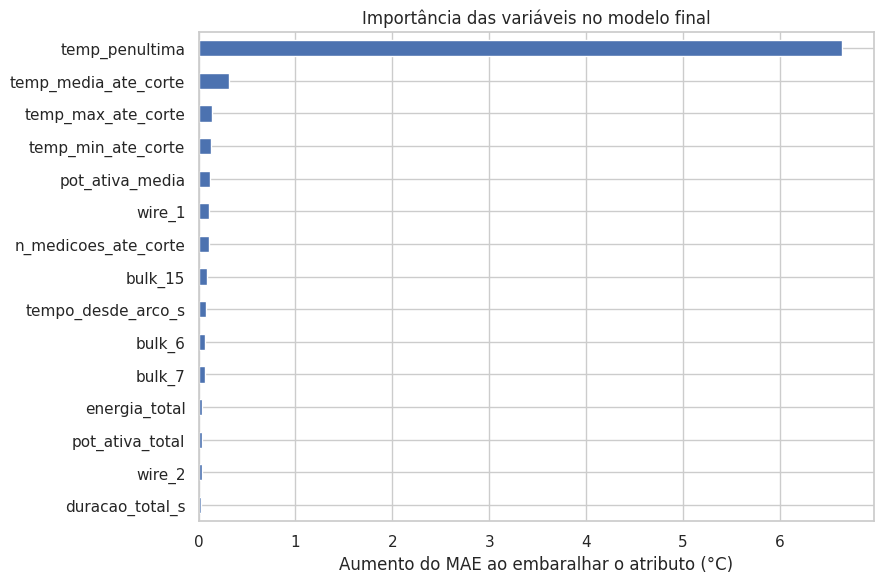

Quinze atributos mais importantes:
temp_penultima          6.637
temp_media_ate_corte    0.313
temp_max_ate_corte      0.134
temp_min_ate_corte      0.129
pot_ativa_media         0.118
wire_1                  0.107
n_medicoes_ate_corte    0.104
bulk_15                 0.082
tempo_desde_arco_s      0.081
bulk_6                  0.068
bulk_7                  0.062
energia_total           0.037
pot_ativa_total         0.033
wire_2                  0.031
duracao_total_s         0.027


In [30]:
importancia = permutation_importance(
    modelo_final, X_teste, y_teste,
    n_repeats=10, random_state=RANDOM_STATE,
    scoring='neg_mean_absolute_error')

ranking = pd.Series(importancia.importances_mean, index=PREDITORES).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(9, 6))
ranking.head(15).sort_values().plot.barh(ax=ax, color='#4c72b0')
ax.set_xlabel('Aumento do MAE ao embaralhar o atributo (°C)')
ax.set_title('Importância das variáveis no modelo final')
plt.tight_layout()
plt.show()

print('Quinze atributos mais importantes:')
print(ranking.head(15).round(3).to_string())

A leitura confirma a física do processo e, ao mesmo tempo, expõe uma limitação.

**A temperatura da penúltima medição domina.** Embaralhá-la piora o erro em mais de seis graus, enquanto nenhum outro atributo passa de meio grau. O modelo é, em essência, uma correção sobre a última leitura disponível.

Isso não invalida o resultado. A regra de simplesmente repetir essa leitura erra 5,07 °C, e o modelo erra 3,91, o que significa que a correção aprendida vale quase 1,2 °C. Mas delimita o que o modelo é: ele não prevê a temperatura do zero, ele ajusta uma medição recente.

**Os demais atributos relevantes fazem sentido físico.** As estatísticas de temperatura até o corte descrevem a trajetória térmica do lote. `pot_ativa_media` e `tempo_desde_arco_s` capturam o regime de aquecimento e a perda térmica desde o último arco. `wire_1` e `bulk_15` são os materiais de uso mais frequente, identificados na seção 2.3.

Nenhum atributo sem relação plausível com temperatura aparece no topo, o que indica que a base foi construída corretamente.

### 7.2 Análise dos resíduos

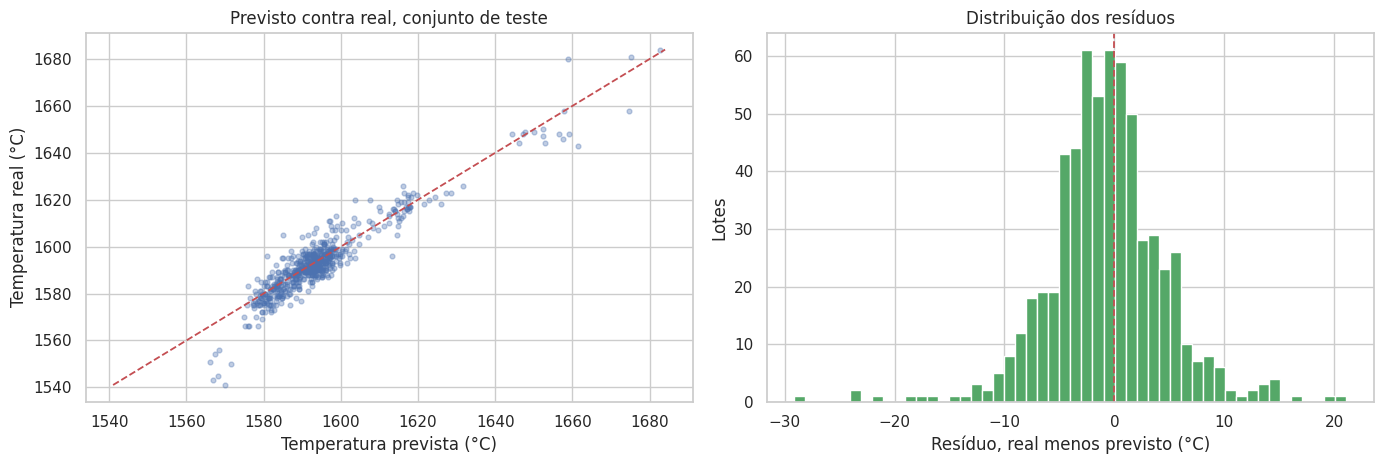

Resíduos no conjunto de teste:
count    618.00
mean      -0.74
std        5.35
min      -29.11
25%       -3.55
50%       -0.81
75%        1.92
max       21.10


In [31]:
residuos = y_teste - previsao_teste

fig, axes = plt.subplots(1, 2, figsize=(14, 4.8))

axes[0].scatter(previsao_teste, y_teste, s=12, alpha=0.35, color='#4c72b0')
limites = [min(y_teste.min(), previsao_teste.min()), max(y_teste.max(), previsao_teste.max())]
axes[0].plot(limites, limites, color='#c44e52', linestyle='--', linewidth=1.3)
axes[0].set_xlabel('Temperatura prevista (°C)')
axes[0].set_ylabel('Temperatura real (°C)')
axes[0].set_title('Previsto contra real, conjunto de teste')

axes[1].hist(residuos, bins=50, color='#55a868', edgecolor='white')
axes[1].axvline(0, color='#c44e52', linestyle='--', linewidth=1.3)
axes[1].set_xlabel('Resíduo, real menos previsto (°C)')
axes[1].set_ylabel('Lotes')
axes[1].set_title('Distribuição dos resíduos')

plt.tight_layout()
plt.show()

print('Resíduos no conjunto de teste:')
print(residuos.describe().round(2).to_string())

Os resíduos se concentram em torno de zero, com média ligeiramente negativa. O modelo prevê, em média, um valor um pouco acima do real.

Esse viés é consequência direta da deriva identificada na seção 4.1. O modelo foi treinado em um período mais quente e aplicado a um período mais frio, e a diferença entre as médias dos dois conjuntos é da mesma ordem do viés observado. Em produção isso seria corrigido por retreinamento periódico.

A cauda dos resíduos é assimétrica, com erros negativos mais extremos que os positivos, o que é coerente com a razão entre RMSE e MAE observada na seção 6.3.

### 7.3 Erro por faixa de temperatura

O MAE global esconde variação de desempenho entre faixas. Como a seção 4.5 antecipou, o modelo tende a acertar o centro da distribuição e errar mais nos extremos, que são justamente os lotes de maior interesse operacional.

,lotes,mae,erro_maximo
temp_final,,,
"(1540.999, 1586.0]",162,4.76,29.11
"(1586.0, 1592.0]",169,2.95,9.76
"(1592.0, 1597.0]",144,2.94,17.16
"(1597.0, 1684.0]",143,5.06,21.10


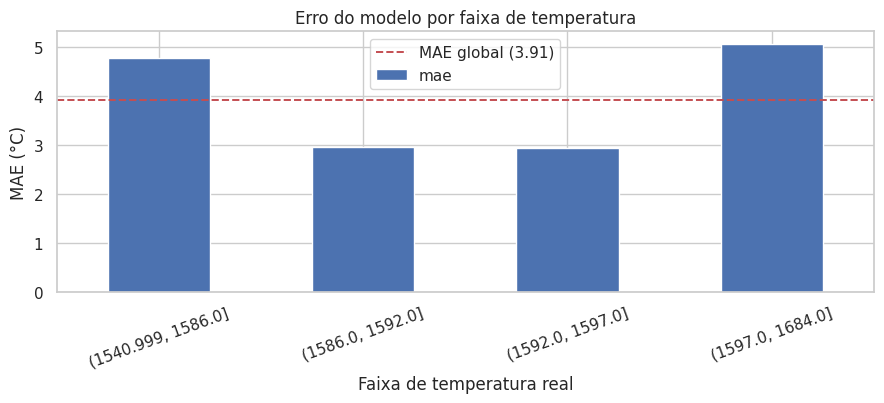

In [32]:
faixas = pd.qcut(y_teste, 4)

erro_por_faixa = pd.DataFrame({
    'temperatura_real': y_teste,
    'erro_absoluto'   : residuos.abs(),
}).groupby(faixas)['erro_absoluto'].agg(['count', 'mean', 'max']).round(2)

erro_por_faixa.columns = ['lotes', 'mae', 'erro_maximo']
display(erro_por_faixa)

fig, ax = plt.subplots(figsize=(9, 4.2))
erro_por_faixa['mae'].plot.bar(ax=ax, color='#4c72b0')
ax.axhline(mae_final, color='#c44e52', linestyle='--', linewidth=1.4,
           label=f'MAE global ({mae_final:.2f})')
ax.set_ylabel('MAE (°C)')
ax.set_xlabel('Faixa de temperatura real')
ax.set_title('Erro do modelo por faixa de temperatura')
ax.legend()
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

O erro tem formato de U. Nos dois quartis centrais o MAE fica bem abaixo da média global, e nos quartis extremos sobe acima dela. O maior erro individual ocorre no quartil mais frio.

A consequência prática importa para a recomendação operacional: a previsão é mais confiável em lotes de comportamento típico e menos confiável justamente nos lotes atípicos, que costumam ser os que mais consomem energia. O modelo deve ser usado como apoio à decisão, com atenção redobrada quando o lote já vem fora da faixa usual.

### 7.4 Comparação entre as versões da base

O plano da Etapa 1 previu a construção da base em duas versões para quantificar o efeito do recorte temporal. A base acumulada usa somas sobre o lote inteiro, que só existem quando o tratamento termina, e por isso não é utilizável na operação. Ela serve como teto de referência.

In [33]:
base_acu_ordenada = base_acumulada.loc[
    [k for k in ordem_cronologica if k in base_acumulada.index]]

corte_acu = int(len(base_acu_ordenada) * PROPORCAO_TREINO)
treino_acu = base_acu_ordenada.iloc[:corte_acu]
teste_acu  = base_acu_ordenada.iloc[corte_acu:]

preditores_acu = [c for c in base_acumulada.columns if c != ALVO]

modelo_acumulado = CatBoostRegressor(random_state=RANDOM_STATE, verbose=0,
                                     **buscas['CatBoost'].best_params_)
modelo_acumulado.fit(treino_acu[preditores_acu], treino_acu[ALVO])

mae_acumulado = mean_absolute_error(teste_acu[ALVO],
                                    modelo_acumulado.predict(teste_acu[preditores_acu]))

print(f'MAE com a base recortada (oficial)  : {mae_final:.2f} °C')
print(f'MAE com a base acumulada (referência): {mae_acumulado:.2f} °C')
print(f'\nDiferença: {mae_final - mae_acumulado:.2f} °C '
      f'({(mae_final - mae_acumulado) / mae_final * 100:.1f}% do erro do modelo oficial)')

MAE com a base recortada (oficial)  : 3.91 °C
MAE com a base acumulada (referência): 3.55 °C

Diferença: 0.36 °C (9.2% do erro do modelo oficial)


A diferença é pequena, e essa é a conclusão relevante.

Se o recorte temporal tivesse sido ignorado, o notebook reportaria um erro cerca de 0,4 °C menor. Esse ganho seria ilusório: viria de informar ao modelo a energia total aplicada no lote, incluindo o aquecimento que ainda não ocorreu no momento da previsão. O modelo pareceria melhor e funcionaria pior na planta.

O fato de a diferença ser pequena mostra que o desempenho se apoia principalmente nas variáveis de estado térmico, que estão disponíveis no momento da decisão, e não na informação futura. O modelo é robusto no sentido que importa.

### 7.5 Análise de sensibilidade à forma de divisão

A seção 4.1 trocou a divisão aleatória estratificada pela cronológica, por causa da deriva. Convém verificar o quanto essa escolha afetou o resultado.

In [34]:
X_alea_treino, X_alea_teste, y_alea_treino, y_alea_teste = train_test_split(
    base_recortada[PREDITORES], base_recortada[ALVO],
    test_size=0.25, random_state=RANDOM_STATE)

modelo_alea = CatBoostRegressor(random_state=RANDOM_STATE, verbose=0,
                                **buscas['CatBoost'].best_params_)
modelo_alea.fit(X_alea_treino, y_alea_treino)

mae_aleatoria = mean_absolute_error(y_alea_teste, modelo_alea.predict(X_alea_teste))

print(f'MAE com divisão cronológica (adotada) : {mae_final:.2f} °C')
print(f'MAE com divisão aleatória              : {mae_aleatoria:.2f} °C')
print(f'Diferença                              : {abs(mae_final - mae_aleatoria):.2f} °C')

MAE com divisão cronológica (adotada) : 3.91 °C
MAE com divisão aleatória              : 3.87 °C
Diferença                              : 0.04 °C


Os dois resultados são praticamente idênticos, o que é uma boa notícia em dois sentidos.

O modelo não depende de ter visto lotes contemporâneos aos do teste, ou seja, generaliza através do período. E a decisão pela divisão cronológica não penalizou o resultado, o que significa que a escolha mais conservadora foi adotada sem custo.

Se as duas estimativas divergissem muito, seria sinal de que a deriva compromete a validade do modelo ao longo do tempo, o que exigiria retreinamento frequente.

## 8. Resumo dos resultados

### 8.1 Desempenho consolidado

In [35]:
def metricas_no_teste(previsao):
    return {
        'MAE'  : mean_absolute_error(y_teste, previsao),
        'RMSE' : mean_squared_error(y_teste, previsao) ** 0.5,
        'R2'   : r2_score(y_teste, previsao),
    }

consolidado = pd.DataFrame({
    'Baseline: média do treino'   : metricas_no_teste(np.full(len(y_teste), y_treino.mean())),
    'Baseline: repetir a última'  : metricas_no_teste(X_teste['temp_penultima'].values),
    'Random Forest otimizado'     : metricas_no_teste(otimizados['Random Forest'].predict(X_teste)),
    'CatBoost otimizado (final)'  : metricas_no_teste(previsao_teste),
}).T.round(3)

consolidado['gap_treino_teste_pct'] = [
    np.nan, np.nan,
    diagnostico.loc['Random Forest', 'gap_pct'],
    diagnostico.loc['CatBoost', 'gap_pct'],
]

print('Resultados no conjunto de teste, 618 lotes de julho e agosto de 2019')
display(consolidado.round(2))

print('Atendimento aos KPIs definidos na Etapa 1')
print(f'  MAE abaixo de 4,50 °C        : {mae_final:.2f}  ->  {"atendido" if mae_final < 4.5 else "não atendido"}')
print(f'  R² acima de 0,80             : {r2_final:.3f}  ->  {"atendido" if r2_final > 0.80 else "não atendido"}')
print(f'  Diferença treino/teste < 15% : {diagnostico.loc["CatBoost", "gap_pct"]:.1f}%  ->  '
      f'{"atendido" if diagnostico.loc["CatBoost", "gap_pct"] < 15 else "não atendido"}')

Resultados no conjunto de teste, 618 lotes de julho e agosto de 2019


,MAE,RMSE,R2,gap_treino_teste_pct
Baseline: média do treino,10.64,15.81,-0.02,NaN
Baseline: repetir a última,5.07,6.82,0.81,NaN
Random Forest otimizado,3.97,5.75,0.86,42.20
CatBoost otimizado (final),3.91,5.40,0.88,9.95


Atendimento aos KPIs definidos na Etapa 1
  MAE abaixo de 4,50 °C        : 3.91  ->  atendido
  R² acima de 0,80             : 0.880  ->  atendido
  Diferença treino/teste < 15% : 10.0%  ->  atendido


O modelo final atende aos três critérios definidos no plano de trabalho.

O ponto que sustenta o resultado é a escolha do baseline. Reduzir o erro em relação à média histórica seria trivial, já que qualquer modelo faz isso. A referência exigente é a regra de repetir a última leitura, disponível ao operador sem nenhum esforço, e é sobre ela que o modelo entrega redução de 22,9%.

O Random Forest chegou a erro semelhante, mas foi descartado por não atender ao critério de generalização, com diferença de 42% entre treino e teste contra o limite de 15%.

A tabela também mostra por que o R² tem valor limitado como critério neste problema. A regra ingênua de repetir a última leitura já alcança R² de 0,81, praticamente o limiar definido no plano, sem nenhum modelo por trás. Isso ocorre porque a temperatura anterior explica quase toda a variância do alvo por construção. O R² serve como verificação de sanidade, mas o critério que distingue um modelo útil de um inútil aqui é o MAE medido contra a regra ingênua.

### 8.2 Interpretação no contexto do negócio

A tradução do resultado técnico para o problema da planta passa pela margem de segurança.

Hoje o operador não sabe qual será a temperatura resultante e aquece com margem de segurança para não precisar repetir o ciclo. A incerteza que ele precisa cobrir é a da melhor informação que tem, que é a última leitura, e essa incerteza é de aproximadamente 5,1 °C. Com o modelo, ela cai para 3,9 °C.

A margem que pode ser dispensada é a diferença entre as duas, cerca de 1,2 °C por lote.

In [36]:
amostra = base_recortada[(base_recortada['duracao_total_s'] > 0)].copy()
amostra['ganho_termico'] = amostra['temp_penultima'] - amostra['temp_inicial']
amostra = amostra[amostra['ganho_termico'].abs() < 60]

relacao = LinearRegression().fit(amostra[['duracao_total_s']], amostra['ganho_termico'])
segundos_por_grau = 1 / relacao.coef_[0]

margem_dispensavel = mae_base_repetir - mae_final
lotes_periodo = len(base_recortada)
dias_periodo = (data_lote.max() - data_lote.min()).days
lotes_por_ano = lotes_periodo / dias_periodo * 365

print(f'Relação estimada a partir dos dados : {segundos_por_grau:.0f} s de arco por °C')
print(f'Duração mediana de arco por lote    : {base_recortada["duracao_total_s"].median():.0f} s')
print()
print(f'Margem de incerteza sem modelo      : {mae_base_repetir:.2f} °C')
print(f'Margem de incerteza com o modelo    : {mae_final:.2f} °C')
print(f'Margem dispensável                  : {margem_dispensavel:.2f} °C')
print()
print(f'Equivalente em tempo de arco por lote : {margem_dispensavel * segundos_por_grau:.0f} s')
print(f'Ritmo observado                       : {lotes_periodo / dias_periodo:.1f} lotes por dia')
print(f'Projeção anual de lotes               : {lotes_por_ano:.0f}')
print(f'Tempo de arco evitado por ano         : '
      f'{margem_dispensavel * segundos_por_grau * lotes_por_ano / 3600:.0f} horas')

Relação estimada a partir dos dados : 31 s de arco por °C
Duração mediana de arco por lote    : 672 s

Margem de incerteza sem modelo      : 5.07 °C
Margem de incerteza com o modelo    : 3.91 °C
Margem dispensável                  : 1.16 °C

Equivalente em tempo de arco por lote : 36 s
Ritmo observado                       : 26.3 lotes por dia
Projeção anual de lotes               : 9595
Tempo de arco evitado por ano         : 95 horas


A relação entre tempo de arco e ganho térmico foi estimada por regressão sobre os próprios lotes, e não assumida de fora.

O resultado dá ordem de grandeza ao ganho. A margem dispensável por lote equivale a algo em torno de meio minuto de arco, o que parece pouco isoladamente. Multiplicado pelo ritmo observado de 26 lotes por dia, vira cerca de cem horas de arco por ano, com efeito direto sobre três frentes: consumo de energia elétrica, desgaste de eletrodo de grafite, proporcional ao tempo de arco, e tempo de ocupação da panela, que limita a vazão da aciaria.

Os valores acima são estimativa de ordem de grandeza e não substituem o cálculo econômico da área de custos, que dispõe do preço de energia e do custo de eletrodo. O que este notebook estabelece é a base física do ganho: quanto de aquecimento deixa de ser aplicado por lote.

A recomendação operacional decorrente é usar a previsão como apoio à decisão de aquecimento, com atenção reforçada nos lotes das faixas extremas de temperatura, onde a seção 7.3 mostrou erro acima da média.

### 8.3 Limitações

**Dos dados.**

O período cobre 94 dias, de maio a agosto de 2019. Não há como avaliar sazonalidade anual nem verificar se a deriva observada continua, se estabiliza ou se inverte em prazo maior.

O arquivo de gás inerte traz apenas o total por lote, sem horário. Isso impediu seu recorte temporal e o excluiu da base oficial. A correlação medida na Etapa 1 era baixa, então a perda provavelmente é pequena, mas não é verificável.

Os identificadores de material são anônimos. Sem saber o que cada coluna representa, não é possível distinguir se um material influencia a temperatura por efeito próprio ou se apenas marca um tipo de aço com especificação diferente. A pergunta 6 da Etapa 1 pedia essa informação e não foi respondida.

Não há registro do tipo de aço nem da temperatura-alvo de cada lote. Parte da variação que o modelo não explica pode ser simplesmente diferença de produto.

**Do modelo.**

A importância se concentra fortemente na penúltima medição de temperatura. O modelo funciona como uma correção sobre a última leitura disponível, e não como previsão construída a partir do processo. Isso é adequado ao uso pretendido, mas significa que ele depende de haver medição recente e não seria aplicável antes do primeiro aquecimento.

O erro tem formato de U por faixa de temperatura, com desempenho pior justamente nos lotes atípicos, que são os de maior interesse operacional.

Os resíduos têm viés levemente negativo, herdado da deriva entre os períodos de treino e teste. Em produção isso exigiria retreinamento periódico para acompanhar o processo.

A hipótese sobre o momento de uso da previsão não foi confirmada. Todo o desenho assume o Cenário B, com previsão entre iterações. Se o uso pretendido for anterior ao primeiro aquecimento, a base de atributos e o KPI precisam ser refeitos, conforme registrado na seção 4.3 do plano de trabalho.